# Fraud Detection — PCA + K-Fold Cross Validation + Logistic Regression

**Approach:**
1. Engineer features from balance discrepancies and transaction patterns
2. Use PCA to reduce dimensionality and remove correlated features
3. Evaluate with Stratified K-Fold CV (preserves fraud class ratio per fold)
4. Final model: Logistic Regression trained on PCA components

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
df = pd.read_csv('Financial_Fraud_dataset.csv')
print(f"Full dataset shape: {df.shape}")
print(f"Overall fraud rate: {df['isFraud'].mean()*100:.4f}%")

Full dataset shape: (6362620, 11)
Overall fraud rate: 0.1291%


## 2. Feature Engineering

Fraud only occurs in `TRANSFER` and `CASH_OUT` transactions — filtering first cuts the dataset nearly in half and removes guaranteed negatives.

In [3]:
# Filter to transaction types where fraud actually occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Filtered shape: {df.shape}")
print(f"Fraud rate after filter: {df['isFraud'].mean()*100:.4f}%")

# Encode transaction type (1 = TRANSFER, 0 = CASH_OUT)
df['type_encoded'] = (df['type'] == 'TRANSFER').astype(int)

# Balance error features — key fraud signal
# If origin balance doesn't decrease by the amount, something is off
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# If destination balance doesn't increase by the amount, something is off
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Account fully drained (common in fraud: empty the account and run)
df['origDrained'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)

# Destination balance suspiciously unchanged after receiving funds
df['destUnchanged'] = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)

# Log-transform amount to reduce skew
df['log_amount'] = np.log1p(df['amount'])

print("\nEngineered features added.")
df[['errorBalanceOrig', 'errorBalanceDest', 'origDrained', 'destUnchanged', 'log_amount']].describe()

Filtered shape: (2770409, 11)
Fraud rate after filter: 0.2965%

Engineered features added.


,errorBalanceOrig,errorBalanceDest,origDrained,destUnchanged,log_amount
count,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06
mean,2.859850e+05,-2.864713e+04,4.288443e-01,2.090666e-03,1.192780e+01
std,8.753230e+05,5.934794e+05,4.949111e-01,4.567599e-02,1.232817e+00
min,-1.000000e-02,-7.588573e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.185310e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.132629e+01
50%,1.435971e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.205095e+01
75%,2.798912e+05,0.000000e+00,1.000000e+00,0.000000e+00,1.263393e+01
max,9.244552e+07,1.000000e+07,1.000000e+00,1.000000e+00,1.834213e+01


## 3. Prepare Feature Matrix

In [4]:
FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded'
]

X = df[FEATURES].values
y = df['isFraud'].values

print(f"Feature matrix: {X.shape}")
print(f"Fraud cases: {y.sum():,} ({y.mean()*100:.4f}%)")
print(f"Legitimate cases: {(y==0).sum():,}")

Feature matrix: (2770409, 10)
Fraud cases: 8,213 (0.2965%)
Legitimate cases: 2,762,196


## 4. PCA — Explained Variance Analysis

We scale first (PCA is sensitive to feature magnitudes), then examine how many components are needed to retain 95% of the variance.

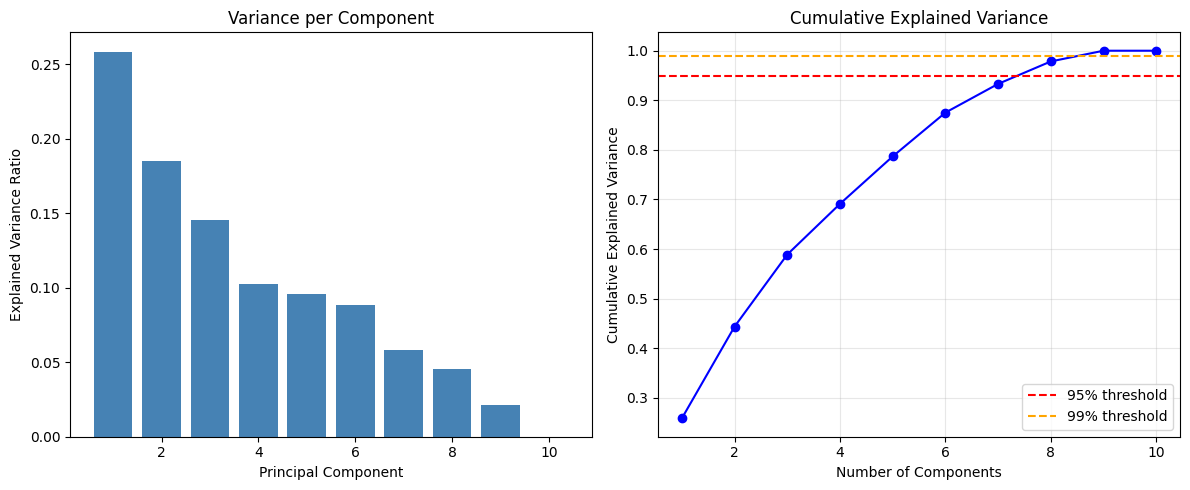

Components for 95% variance: 8
Components for 99% variance: 9


In [5]:
# NOTE: For large datasets, we fit PCA on a sample to get component counts quickly
# The actual pipeline will fit on full training folds
sample_idx = np.random.choice(len(X), size=min(100_000, len(X)), replace=False)
X_sample = StandardScaler().fit_transform(X[sample_idx])

pca_full = PCA()
pca_full.fit(X_sample)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance per Component')

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95)) + 1
n_components_99 = int(np.argmax(cumulative >= 0.99)) + 1
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

N_COMPONENTS = n_components_95  # Use 95% threshold

## 5. PCA Component Loadings

Understanding what each principal component captures helps interpret model decisions.

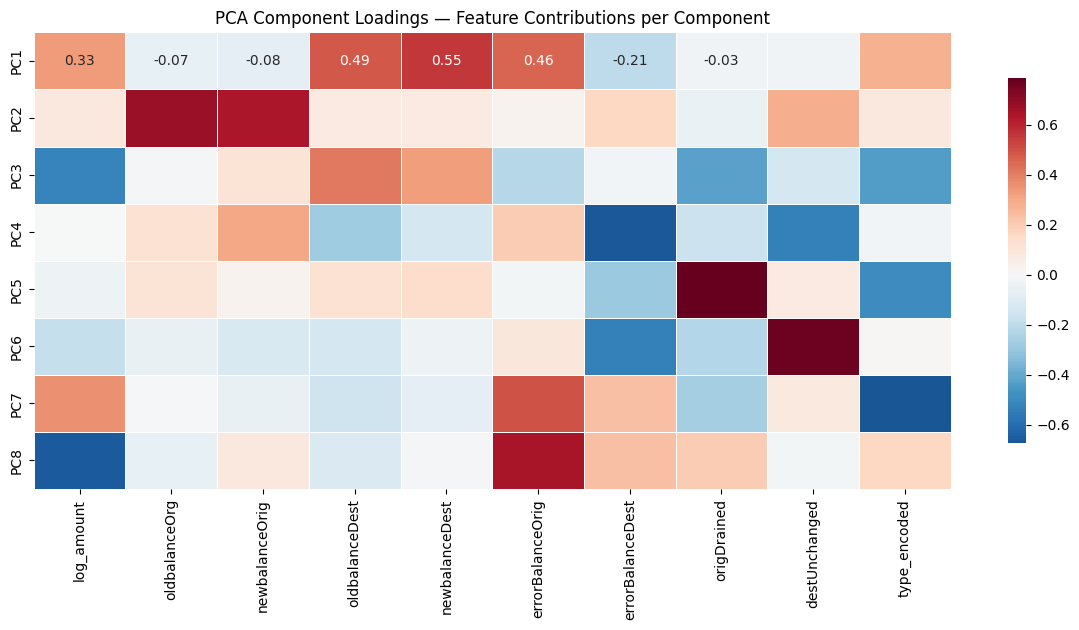

In [6]:
pca_viz = PCA(n_components=N_COMPONENTS)
scaler_viz = StandardScaler()
pca_viz.fit(scaler_viz.fit_transform(X[sample_idx]))

loadings = pd.DataFrame(
    pca_viz.components_,
    columns=FEATURES,
    index=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

plt.figure(figsize=(12, max(4, N_COMPONENTS * 0.8)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('PCA Component Loadings — Feature Contributions per Component')
plt.tight_layout()
plt.show()

## 5b. Hyperparameter Tuning — Grid Search for C

The Logistic Regression `C` parameter controls **regularization strength** (smaller C = stronger regularization = simpler model). We grid-search over three values using 3-fold stratified CV on a 200k-row sample for speed, scoring by **PR-AUC** to match our primary evaluation metric.

In [ ]:
from sklearn.model_selection import cross_val_score

C_VALUES = [0.01, 0.1, 1.0]

# Sample for speed (full 2.7M rows × 3 folds × 3 C values is slow)
sample_size = min(200_000, len(X))
rng = np.random.default_rng(42)
sample_idx_gs = rng.choice(len(X), size=sample_size, replace=False)
X_gs = X[sample_idx_gs]
y_gs = y[sample_idx_gs]

print("Grid Search: Tuning Logistic Regression C parameter")
print(f"Sample size: {sample_size:,} rows | 3-fold stratified CV | scored by PR-AUC\n")
print(f"{'C Value':<12} {'PR-AUC Mean':>12} {'PR-AUC Std':>12}")
print("-" * 38)

gs_results = []
for C in C_VALUES:
    pipe_gs = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=N_COMPONENTS)),
        ('clf',    LogisticRegression(
                       C=C,
                       class_weight='balanced',
                       max_iter=1000,
                       solver='lbfgs',
                       random_state=42
                   ))
    ])
    skf_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe_gs, X_gs, y_gs, cv=skf_gs,
                             scoring='average_precision', n_jobs=-1)
    gs_results.append({'C': C, 'mean': scores.mean(), 'std': scores.std()})
    print(f"{C:<12} {scores.mean():>12.4f} {scores.std():>12.4f}")

gs_df = pd.DataFrame(gs_results)
best_C = gs_df.loc[gs_df['mean'].idxmax(), 'C']
print(f"\nBest C: {best_C}")

## 6. Stratified K-Fold Cross Validation

**Why Stratified?** With only 0.13% fraud, a random split could put almost no fraud cases in a fold. Stratified K-Fold guarantees each fold has the same fraud proportion as the full dataset.

**Pipeline approach:** Scaler → PCA → Logistic Regression. Fitting the entire pipeline inside each fold prevents data leakage (the scaler and PCA never see the validation data during fitting).

In [ ]:
N_SPLITS = 5

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=N_COMPONENTS)),
    ('clf',    LogisticRegression(
                   C=best_C,             # tuned via grid search above
                   class_weight='balanced',
                   max_iter=1000,
                   solver='lbfgs',
                   random_state=42
               ))
])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_results = []
print(f"Running {N_SPLITS}-Fold Stratified CV on {len(X):,} samples (C={best_C})...\n")
print(f"{'Fold':<6} {'F1':>8} {'PR-AUC':>10} {'ROC-AUC':>10}")
print("-" * 38)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    pipeline.fit(X_train_f, y_train_f)
    y_pred_f  = pipeline.predict(X_val_f)
    y_proba_f = pipeline.predict_proba(X_val_f)[:, 1]

    f1     = f1_score(y_val_f, y_pred_f)
    pr_auc = average_precision_score(y_val_f, y_proba_f)
    roc    = roc_auc_score(y_val_f, y_proba_f)

    fold_results.append({'fold': fold, 'f1': f1, 'pr_auc': pr_auc, 'roc_auc': roc})
    print(f"{fold:<6} {f1:>8.4f} {pr_auc:>10.4f} {roc:>10.4f}")

metrics_df = pd.DataFrame(fold_results)
print("-" * 38)
print(f"{'Mean':<6} {metrics_df['f1'].mean():>8.4f} {metrics_df['pr_auc'].mean():>10.4f} {metrics_df['roc_auc'].mean():>10.4f}")
print(f"{'Std':<6} {metrics_df['f1'].std():>8.4f} {metrics_df['pr_auc'].std():>10.4f} {metrics_df['roc_auc'].std():>10.4f}")

## 7. K-Fold Metric Visualization

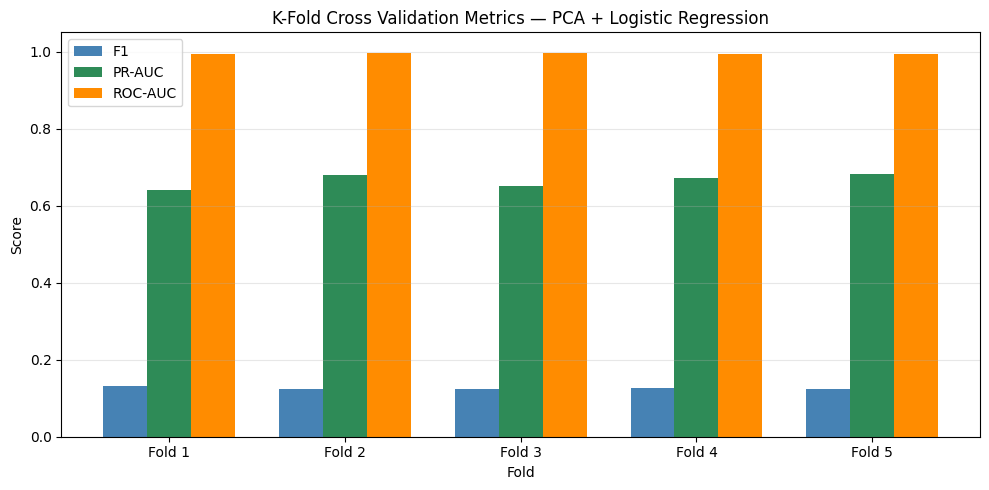

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(N_SPLITS)
width = 0.25
ax.bar(x - width, metrics_df['f1'],     width, label='F1',      color='steelblue')
ax.bar(x,         metrics_df['pr_auc'], width, label='PR-AUC',  color='seagreen')
ax.bar(x + width, metrics_df['roc_auc'],width, label='ROC-AUC', color='darkorange')

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('K-Fold Cross Validation Metrics — PCA + Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Final Evaluation — Last Fold as Held-Out Test Set

In [9]:
# Re-use the last fold split as a representative test set
train_idx, test_idx = list(skf.split(X, y))[-1]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report (default 0.5 threshold):")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Classification Report (default 0.5 threshold):
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    552439
       Fraud       0.07      0.99      0.12      1642

    accuracy                           0.96    554081
   macro avg       0.53      0.98      0.55    554081
weighted avg       1.00      0.96      0.98    554081



## 9. Confusion Matrix

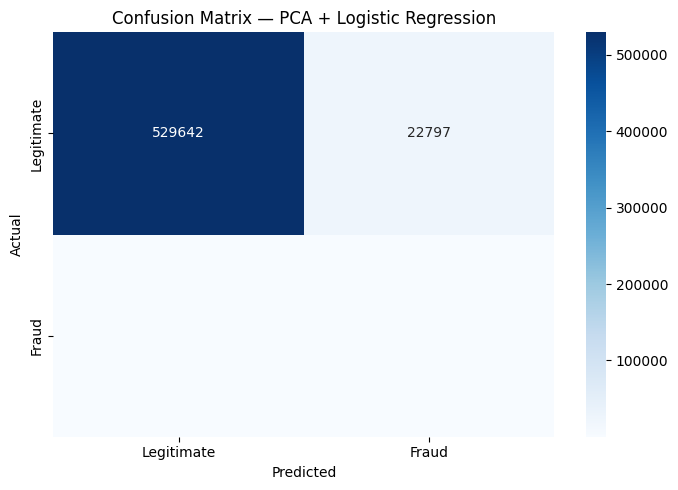

True Positives  (caught fraud):   1,628
False Negatives (missed fraud):   14
False Positives (false alarms):   22,797
True Negatives  (correct legit):  529,642


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — PCA + Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (caught fraud):   {tp:,}")
print(f"False Negatives (missed fraud):   {fn:,}")
print(f"False Positives (false alarms):   {fp:,}")
print(f"True Negatives  (correct legit):  {tn:,}")

## 10. Precision-Recall Curve & Threshold Tuning

With heavy class imbalance, the default 0.5 threshold is often wrong. We find the threshold that maximizes F1.

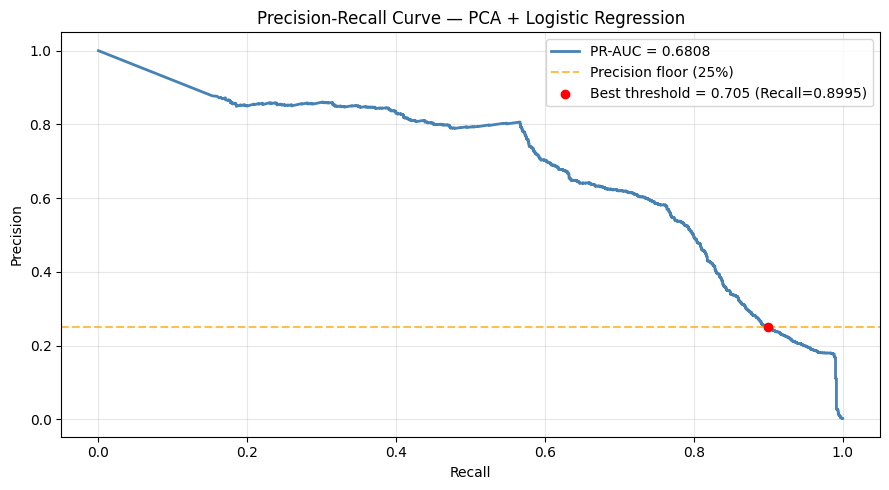

Optimal threshold (max recall @ precision >= 25%): 0.7052
Recall:    0.8995
Precision: 0.2500

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    552439
       Fraud       0.25      0.90      0.39      1642

    accuracy                           0.99    554081
   macro avg       0.62      0.95      0.69    554081
weighted avg       1.00      0.99      0.99    554081



In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Maximize recall subject to precision >= 10% floor
# Pure recall maximization flags everything as fraud (useless);
# a 25% floor means 2.5 in 10 flagged transactions is real fraud — operationally realistic
PRECISION_FLOOR = 0.1
valid = precision[:-1] >= PRECISION_FLOOR
best_idx    = np.argmax(recall[:-1] * valid)  # highest recall among valid thresholds
best_thresh = thresholds[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.axhline(y=PRECISION_FLOOR, color='orange', linestyle='--', alpha=0.7, label=f'Precision floor ({PRECISION_FLOOR:.0%})')
plt.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best threshold = {best_thresh:.3f} (Recall={recall[best_idx]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — PCA + Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold (max recall @ precision >= {PRECISION_FLOOR:.0%}): {best_thresh:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")

y_pred_opt = (y_proba >= best_thresh).astype(int)
print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['Legitimate', 'Fraud']))

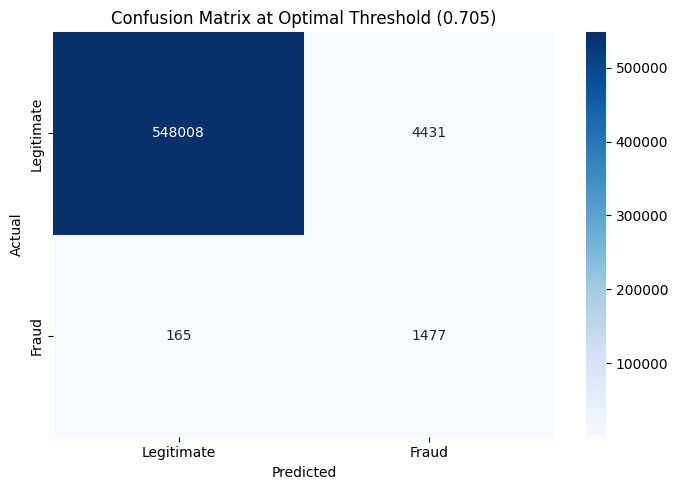

True Positives  (caught fraud):   1,477
False Negatives (missed fraud):   165
False Positives (false alarms):   4,431
True Negatives  (correct legit):  548,008

Recall:    0.8995  (fraud cases caught)
Precision: 0.2500  (of flagged, actually fraud)


In [24]:
y_pred_opt = (y_proba >= best_thresh).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix at Optimal Threshold ({best_thresh:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Positives  (caught fraud):   {tp:,}")
print(f"False Negatives (missed fraud):   {fn:,}")
print(f"False Positives (false alarms):   {fp:,}")
print(f"True Negatives  (correct legit):  {tn:,}")
print(f"\nRecall:    {tp / (tp + fn):.4f}  (fraud cases caught)")
print(f"Precision: {tp / (tp + fp):.4f}  (of flagged, actually fraud)")